In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [18]:
df = pd.read_csv('injection_molding.csv')
df.drop(columns=['timestamp'], inplace=True)
df.head(1)

,mold_name,material_name,machine_tonnage,cycle_number,hopper_temp,nozzle_temp,H1,H2,H3,mold_core_temp,...,total_cycle_time,Hopper_State,Barrel_Heater_State,Screw_State,Injection_Unit_State,Hydraulic_System_State,Clamp_Unit_State,Mold_State,Cooling_System_State,Ejector_System_State
0,Smart Router Enclosure,"ABS (Flame Retardant, Medium Flow)",180,1,45,230,225,211,201,67,...,24.61,0,0,0,0,0,0,0,0,0


In [19]:
target = ['Hopper_State','Barrel_Heater_State', 'Screw_State', 'Injection_Unit_State','Hydraulic_System_State', 
               'Clamp_Unit_State', 'Mold_State','Cooling_System_State', 'Ejector_System_State']  
sensor = [i for i in df.columns if i not in target]
sensor.remove('mold_name')
sensor.remove('material_name')
len(sensor)

34

In [20]:
def find_correlation(corr, threshold=0.95):
    """Iteratively drop the more globally-redundant column of the most-correlated
    remaining pair, until no pair exceeds threshold. Avoids over-pruning chains."""
    corr = corr.abs().copy()
    vals = corr.values.copy()
    np.fill_diagonal(vals, 0)  # ignore self-correlation
    corr = pd.DataFrame(vals, index=corr.index, columns=corr.columns)
    to_drop = []
    while True:
        max_corr = corr.values.max()
        if max_corr <= threshold or corr.shape[0] <= 1:
            break
        i, j = np.unravel_index(np.argmax(corr.values), corr.shape)
        col_i, col_j = corr.index[i], corr.columns[j]
        # drop whichever has the higher average correlation with everything else remaining
        drop_col = col_i if corr[col_i].mean() > corr[col_j].mean() else col_j
        to_drop.append(drop_col)
        corr = corr.drop(index=drop_col, columns=drop_col)
    return to_drop

# correlation-based pruning of redundant raw sensor columns
corr = df[sensor].corr()
to_drop = find_correlation(corr, threshold=0.95)
kept_numeric_cols = [c for c in sensor if c not in to_drop]
df.drop(columns=to_drop, inplace=True)
print(f"Dropped {len(to_drop)} redundant (|r|>0.95) columns, kept {len(kept_numeric_cols)}:")
print(kept_numeric_cols)

Dropped 18 redundant (|r|>0.95) columns, kept 16:
['cycle_number', 'hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed1', 'actual_inj_pressure', 'vp_transition', 'holding_pressure_stage2', 'back_pressure', 'decompression_speed', 'decompression_distance', 'cushion_size', 'clamp_force', 'mold_protection_pressure', 'ejection_stroke', 'part_weight']


In [21]:
to_drop

['holding_pressure_stage3',
 'H3',
 'total_cycle_time',
 'inj_speed2',
 'mold_core_temp',
 'nozzle_temp',
 'inj_speed3',
 'H2',
 'cooling_time',
 'machine_tonnage',
 'screw_rpm',
 'mold_open_reset_time',
 'mold_close_speed',
 'screw_diameter',
 'shot_weight',
 'holding_pressure_stage1',
 'inj_time_actual',
 'ejection_speed']

In [22]:
df.columns

Index(['mold_name', 'material_name', 'cycle_number', 'hopper_temp', 'H1',
       'mold_cavity_temp', 'inj_speed1', 'actual_inj_pressure',
       'vp_transition', 'holding_pressure_stage2', 'back_pressure',
       'decompression_speed', 'decompression_distance', 'cushion_size',
       'clamp_force', 'mold_protection_pressure', 'ejection_stroke',
       'part_weight', 'Hopper_State', 'Barrel_Heater_State', 'Screw_State',
       'Injection_Unit_State', 'Hydraulic_System_State', 'Clamp_Unit_State',
       'Mold_State', 'Cooling_System_State', 'Ejector_System_State'],
      dtype='str')

# Train Test  Split

In [23]:
import pandas as pd 
train_list = []
val_list = []
test_list = []
for mold_id, group in df.groupby('mold_name'):
    n = len(group)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    train_list.append(group.iloc[:train_end])
    val_list.append(group.iloc[train_end:val_end])
    test_list.append(group.iloc[val_end:])
train_df = pd.concat(train_list).reset_index(drop=True)
val_df = pd.concat(val_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)
print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

Train: (28000, 27)
Validation: (6000, 27)
Test: (6000, 27)


In [24]:
window = 5
temp_pressure  = ['hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed1','holding_pressure_stage2', 'back_pressure', 'decompression_speed','mold_protection_pressure', 'ejection_stroke', 'part_weight']

def add_engineered_features(data, window=window, temp_pressure=temp_pressure, kept_numeric_cols=kept_numeric_cols):
    data = data.sort_values(['mold_name', 'cycle_number']).reset_index(drop=True)
    grp = data.groupby('mold_name')

    # rolling mean & std
    roll_mean = grp[temp_pressure].rolling(window, min_periods=1).mean().droplevel(0)
    roll_mean.columns = [f'{c}_roll_mean' for c in temp_pressure]

    roll_std = grp[temp_pressure].rolling(window, min_periods=1).std().droplevel(0)
    roll_std.columns = [f'{c}_roll_std' for c in temp_pressure]

    # delta
    delta = grp[kept_numeric_cols].diff()
    delta.columns = [f'{c}_delta' for c in kept_numeric_cols]

    eng = pd.concat([roll_mean, roll_std, delta], axis=1).sort_index().fillna(0.0)
    return pd.concat([data, eng], axis=1)

train_df = add_engineered_features(train_df)
val_df = add_engineered_features(val_df)
test_df = add_engineered_features(test_df)

print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

Train: (28000, 63)
Validation: (6000, 63)
Test: (6000, 63)


In [25]:
#ohe on mold id
def add_mold_dummies(data):
    enc = pd.get_dummies(data['mold_name'], prefix='mold_name', dtype=int)
    return pd.concat([enc,data], axis=1)

train_df = add_mold_dummies(train_df)
val_df = add_mold_dummies(val_df)
test_df = add_mold_dummies(test_df)

In [26]:
train_df.columns

Index(['mold_name_Blood Filtration Housing', 'mold_name_Engine Mount Bracket',
       'mold_name_Rectangular Food Container',
       'mold_name_Smart Router Enclosure', 'mold_name', 'material_name',
       'cycle_number', 'hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed1',
       'actual_inj_pressure', 'vp_transition', 'holding_pressure_stage2',
       'back_pressure', 'decompression_speed', 'decompression_distance',
       'cushion_size', 'clamp_force', 'mold_protection_pressure',
       'ejection_stroke', 'part_weight', 'Hopper_State', 'Barrel_Heater_State',
       'Screw_State', 'Injection_Unit_State', 'Hydraulic_System_State',
       'Clamp_Unit_State', 'Mold_State', 'Cooling_System_State',
       'Ejector_System_State', 'hopper_temp_roll_mean', 'H1_roll_mean',
       'mold_cavity_temp_roll_mean', 'inj_speed1_roll_mean',
       'holding_pressure_stage2_roll_mean', 'back_pressure_roll_mean',
       'decompression_speed_roll_mean', 'mold_protection_pressure_roll_mean',
       'eje

In [27]:
# scaling numeric features
scaler = StandardScaler()
id_cat_cols = ['mold_name', 'material_name']
mold_dummy_cols = [c for c in train_df.columns if c.startswith('mold_name_')]

exclude_cols = id_cat_cols + target + mold_dummy_cols

numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
val_df[numeric_cols] = scaler.transform(val_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

In [28]:
train_df.drop(columns=['mold_name','material_name'],inplace=True)
val_df.drop(columns=['mold_name','material_name'],inplace=True)
test_df.drop(columns=['mold_name','material_name'],inplace=True)

In [29]:
def reorder_target_last(data, target=target):
    cols = [c for c in data.columns if c not in target] + target
    return data[cols]

train_df = reorder_target_last(train_df)
val_df = reorder_target_last(val_df)
test_df = reorder_target_last(test_df)

X_train, y_train = train_df.drop(columns=target), train_df[target]
X_val, y_val = val_df.drop(columns=target), val_df[target]
X_test, y_test = test_df.drop(columns=target), test_df[target]

# Anomaly/ Novelty detection

Same 5 algorithms as the "Per-Subsystem Anomaly Detection (9 targets)" section of `maintenance_model_building.ipynb` — **Isolation Forest, ECOD, COPOD, LOF, Autoencoder** — fit independently per subsystem target. The difference: instead of feeding every column to every target's detectors, each target only sees the sensor column(s) that `synthetic_data_eda.ipynb` (section 7, *"Do the sensor features actually relate to their matching component state?"*) showed actually move with that subsystem's state (the boxplot check + its follow-up feature-importance check).

For each target column `col`:
- Train only on `train_df` rows where `col == 0` (healthy for *that* subsystem specifically).
- Feature set: `target_feature_map[col]` — the EDA-identified raw column for that target, plus its engineered `_roll_mean` / `_roll_std` / `_delta` variants where available.
- Score every row of `train_df`/`val_df`/`test_df`, stored as `f'{col}_{algo}_score'`.
- Evaluate on val/test with PR-AUC, ROC-AUC, Recall, ground truth `col != 0`.

Note: 3 of the EDA boxplot's columns (`mold_close_speed` for Clamp, `cooling_time` for Cooling, `ejection_speed` for Ejector) got dropped earlier by the `|r|>0.95` correlation pruning, so they no longer exist in `train_df`. For those, the closest still-available column — by the EDA's RandomForest feature-importance ranking against that target — is used instead: `mold_protection_pressure` + `clamp_force` for `Clamp_Unit_State`, `mold_cavity_temp` for `Cooling_System_State`, `ejection_stroke` for `Ejector_System_State`.

In [30]:
df.columns

Index(['mold_name', 'material_name', 'cycle_number', 'hopper_temp', 'H1',
       'mold_cavity_temp', 'inj_speed1', 'actual_inj_pressure',
       'vp_transition', 'holding_pressure_stage2', 'back_pressure',
       'decompression_speed', 'decompression_distance', 'cushion_size',
       'clamp_force', 'mold_protection_pressure', 'ejection_stroke',
       'part_weight', 'Hopper_State', 'Barrel_Heater_State', 'Screw_State',
       'Injection_Unit_State', 'Hydraulic_System_State', 'Clamp_Unit_State',
       'Mold_State', 'Cooling_System_State', 'Ejector_System_State'],
      dtype='str')

In [31]:
# Which raw sensor column(s) drive each target, per the EDA check in synthetic_data_eda.ipynb
# section 7 ("Do the sensor features actually relate to their matching component state?").
# For the 3 targets whose EDA column was dropped earlier by the |r|>0.95 correlation pruning
# (mold_close_speed, cooling_time, ejection_speed), the closest still-available column -- by
# RandomForest feature importance against that target, computed in the EDA notebook -- is used instead.
target_base_cols = {
    'Hopper_State': ['hopper_temp'],
    'Barrel_Heater_State': ['H1'],
    'Screw_State': ['back_pressure','decompression_speed','decompression_distance','cushion_size'],
    'Injection_Unit_State': ['actual_inj_pressure','cushion_size','inj_speed1','vp_transition','holding_pressure_stage2'],
    'Hydraulic_System_State': ['clamp_force','actual_inj_pressure','holding_pressure_stage2'],
    'Clamp_Unit_State': ['mold_protection_pressure', 'clamp_force'],  # mold_close_speed dropped -> substitutes
    'Mold_State': ['mold_cavity_temp','part_weight'],
    'Cooling_System_State': ['mold_cavity_temp'],                     # cooling_time dropped -> substitute
    'Ejector_System_State': ['ejection_stroke'],                      # ejection_speed dropped -> substitute
}

def expand_features(base_cols, temp_pressure=temp_pressure, kept_numeric_cols=kept_numeric_cols):
    """Raw column + its engineered roll_mean/roll_std (if in temp_pressure) and delta (if in kept_numeric_cols)."""
    feats = []
    for c in base_cols:
        feats.append(c)
        if c in temp_pressure:
            feats += [f'{c}_roll_mean', f'{c}_roll_std']
        if c in kept_numeric_cols:
            feats.append(f'{c}_delta')
    seen = set()
    return [f for f in feats if not (f in seen or seen.add(f))]

target_feature_map = {col: expand_features(cols) for col, cols in target_base_cols.items()}
for col, feats in target_feature_map.items():
    print(f'{col:24s} -> {feats}')

Hopper_State             -> ['hopper_temp', 'hopper_temp_roll_mean', 'hopper_temp_roll_std', 'hopper_temp_delta']
Barrel_Heater_State      -> ['H1', 'H1_roll_mean', 'H1_roll_std', 'H1_delta']
Screw_State              -> ['back_pressure', 'back_pressure_roll_mean', 'back_pressure_roll_std', 'back_pressure_delta', 'decompression_speed', 'decompression_speed_roll_mean', 'decompression_speed_roll_std', 'decompression_speed_delta', 'decompression_distance', 'decompression_distance_delta', 'cushion_size', 'cushion_size_delta']
Injection_Unit_State     -> ['actual_inj_pressure', 'actual_inj_pressure_delta', 'cushion_size', 'cushion_size_delta', 'inj_speed1', 'inj_speed1_roll_mean', 'inj_speed1_roll_std', 'inj_speed1_delta', 'vp_transition', 'vp_transition_delta', 'holding_pressure_stage2', 'holding_pressure_stage2_roll_mean', 'holding_pressure_stage2_roll_std', 'holding_pressure_stage2_delta']
Hydraulic_System_State   -> ['clamp_force', 'clamp_force_delta', 'actual_inj_pressure', 'actual_inj_

In [32]:
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, recall_score

subsystem_results = []  # (Algorithm, Target, Split, PR_AUC, ROC_AUC, Recall) rows, val/test only

def evaluate_subsystem(algorithm, col, split_name, y_true, y_score, y_pred):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)
    subsystem_results.append({
        'Algorithm': algorithm, 'Target': col, 'Split': split_name,
        'PR_AUC': pr_auc,
        'ROC_AUC': roc_auc_score(y_true, y_score),
        'Recall': recall_score(y_true, y_pred),
    })

### 1. Isolation Forest

In [33]:
from sklearn.ensemble import IsolationForest

iso_forest_subsystem = {}  # target column -> fitted IsolationForest

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    model = IsolationForest(n_estimators=200, contamination='auto', random_state=42, n_jobs=-1)
    model.fit(train_df.loc[healthy_rows, feats])
    iso_forest_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats]
        score = -model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_iso_score'] = score

        if split_name != 'train':  # evaluate only on held-out splits
            pred = (model.predict(X_split) == -1).astype(int)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('Isolation Forest', col, split_name, y_true, score, pred)

print("Isolation Forest: added '<target>_iso_score' to train_df/val_df/test_df for all 9 subsystems.")

Isolation Forest: added '<target>_iso_score' to train_df/val_df/test_df for all 9 subsystems.


### 2. ECOD

In [34]:
from pyod.models.ecod import ECOD

ecod_subsystem = {}

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    model = ECOD(contamination=0.1)
    model.fit(train_df.loc[healthy_rows, feats])
    ecod_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats]
        score = model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_ecod_score'] = score

        if split_name != 'train':
            pred = model.predict(X_split)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('ECOD', col, split_name, y_true, score, pred)

print("ECOD: added '<target>_ecod_score' to train_df/val_df/test_df for all 9 subsystems.")

ECOD: added '<target>_ecod_score' to train_df/val_df/test_df for all 9 subsystems.


### 3. COPOD

In [35]:
from pyod.models.copod import COPOD

copod_subsystem = {}

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    model = COPOD(contamination=0.1)
    model.fit(train_df.loc[healthy_rows, feats])
    copod_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats]
        score = model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_copod_score'] = score

        if split_name != 'train':
            pred = model.predict(X_split)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('COPOD', col, split_name, y_true, score, pred)

print("COPOD: added '<target>_copod_score' to train_df/val_df/test_df for all 9 subsystems.")

COPOD: added '<target>_copod_score' to train_df/val_df/test_df for all 9 subsystems.


### 4. Local Outlier Factor (LOF)

In [36]:
from sklearn.neighbors import LocalOutlierFactor

lof_subsystem = {}

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    model = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination='auto', n_jobs=-1)
    model.fit(train_df.loc[healthy_rows, feats])
    lof_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats]
        score = -model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_lof_score'] = score

        if split_name != 'train':
            pred = (model.predict(X_split) == -1).astype(int)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('LOF', col, split_name, y_true, score, pred)

print("LOF: added '<target>_lof_score' to train_df/val_df/test_df for all 9 subsystems.")

c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\skle

LOF: added '<target>_lof_score' to train_df/val_df/test_df for all 9 subsystems.


c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
c:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


### 5. Autoencoder

In [37]:
import keras
from keras import layers

autoencoder_subsystem = {}

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    X_train_healthy_col = train_df.loc[healthy_rows, feats]

    n_features = X_train_healthy_col.shape[1]
    encoding_dim = max(2, n_features // 4)

    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(encoding_dim, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(n_features, activation='linear'),
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(
        X_train_healthy_col.values, X_train_healthy_col.values,
        epochs=50, batch_size=64, validation_split=0.1,
        shuffle=True, verbose=0,
    )
    autoencoder_subsystem[col] = model

    # threshold from this subsystem's own healthy-training reconstruction error (99th percentile)
    recon_train_healthy = model.predict(X_train_healthy_col.values, verbose=0)
    train_healthy_errors = np.mean(np.square(X_train_healthy_col.values - recon_train_healthy), axis=1)
    ae_threshold = np.percentile(train_healthy_errors, 99)

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats].values
        recon = model.predict(X_split, verbose=0)
        score = np.mean(np.square(X_split - recon), axis=1)  # higher = more anomalous
        split_df[f'{col}_ae_score'] = score

        if split_name != 'train':
            pred = (score > ae_threshold).astype(int)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('Autoencoder', col, split_name, y_true, score, pred)

print("Autoencoder: added '<target>_ae_score' to train_df/val_df/test_df for all 9 subsystems.")

C:\Users\janukrish\AppData\Local\Temp\ipykernel_10972\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score
C:\Users\janukrish\AppData\Local\Temp\ipykernel_10972\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score
C:\Users\janukrish\AppData\Local\Temp\ipykernel_10972\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Conside

Autoencoder: added '<target>_ae_score' to train_df/val_df/test_df for all 9 subsystems.


C:\Users\janukrish\AppData\Local\Temp\ipykernel_10972\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


### Results

In [38]:
# Comparison table: PR-AUC / ROC-AUC / Recall per (Algorithm, Target, Split)
subsystem_results_df = pd.DataFrame(subsystem_results)
subsystem_results_summary = (subsystem_results_df
                              .set_index(['Algorithm', 'Target', 'Split'])[['PR_AUC', 'ROC_AUC', 'Recall']]
                              .round(4))
subsystem_results_summary

PR_AUC  ROC_AUC  Recall
Algorithm        Target               Split                         
Isolation Forest Hopper_State         val    0.4018   0.6627  0.4976
                                      test   0.4632   0.6997  0.5694
                 Barrel_Heater_State  val    0.2760   0.8348  0.8817
                                      test   0.5537   0.8502  0.9143
                 Screw_State          val    0.3893   0.7564  0.5742
...                                             ...      ...     ...
Autoencoder      Mold_State           test   0.2392   0.5583  0.0173
                 Cooling_System_State val    0.1908   0.4832  0.0074
                                      test   0.1254   0.3795  0.0061
                 Ejector_System_State val    0.4670   0.6346  0.0123
                                      test   0.3666   0.5861  0.0120

[90 rows x 3 columns]

In [39]:
subsystem_results_summary[0:18]

PR_AUC  ROC_AUC  Recall
Algorithm        Target                 Split                         
Isolation Forest Hopper_State           val    0.4018   0.6627  0.4976
                                        test   0.4632   0.6997  0.5694
                 Barrel_Heater_State    val    0.2760   0.8348  0.8817
                                        test   0.5537   0.8502  0.9143
                 Screw_State            val    0.3893   0.7564  0.5742
                                        test   0.3037   0.7188  0.4937
                 Injection_Unit_State   val    0.4757   0.7818  0.5120
                                        test   0.6525   0.8012  0.6500
                 Hydraulic_System_State val    0.1226   0.5769  0.2928
                                        test   0.3126   0.5774  0.3817
                 Clamp_Unit_State       val    0.1952   0.6468  0.4386
                                        test   0.2600   0.6911  0.4892
                 Mold_State             val    0.2888   0.6756  0.5312
                                        test   0.3529   0.6272  0.4532
                 Cooling_System_State   val    0.2928   0.6236  0.4880
                                        test   0.3887   0.6793  0.5808
                 Ejector_System_State   val    0.6439   0.8026  0.7506
                                        test   0.4021   0.6512  0.5237

In [40]:
subsystem_results_summary[18:36]

PR_AUC  ROC_AUC  Recall
Algorithm Target                 Split                         
ECOD      Hopper_State           val    0.3271   0.4776  0.1765
                                 test   0.3925   0.4944  0.2446
          Barrel_Heater_State    val    0.0695   0.3029  0.0063
                                 test   0.2858   0.4015  0.1597
          Screw_State            val    0.3515   0.5825  0.2528
                                 test   0.3667   0.5251  0.3919
          Injection_Unit_State   val    0.2889   0.6762  0.2612
                                 test   0.3399   0.6221  0.2492
          Hydraulic_System_State val    0.1051   0.5010  0.0779
                                 test   0.2438   0.4534  0.0523
          Clamp_Unit_State       val    0.1352   0.5281  0.0351
                                 test   0.1758   0.5640  0.0676
          Mold_State             val    0.2736   0.4869  0.2123
                                 test   0.3144   0.4623  0.1991
          Cooling_System_State   val    0.1449   0.3490  0.0157
                                 test   0.2342   0.5587  0.1414
          Ejector_System_State   val    0.5447   0.6502  0.3129
                                 test   0.3000   0.4144  0.1937

In [41]:
subsystem_results_summary[36:54]

PR_AUC  ROC_AUC  Recall
Algorithm Target                 Split                         
COPOD     Hopper_State           val    0.3763   0.5162  0.2005
                                 test   0.4746   0.5427  0.2896
          Barrel_Heater_State    val    0.0833   0.4208  0.0095
                                 test   0.3321   0.4930  0.1643
          Screw_State            val    0.3153   0.5357  0.2341
                                 test   0.3195   0.5116  0.3696
          Injection_Unit_State   val    0.2202   0.6469  0.1602
                                 test   0.2525   0.5530  0.1415
          Hydraulic_System_State val    0.1020   0.5079  0.0327
                                 test   0.2416   0.4539  0.0176
          Clamp_Unit_State       val    0.1800   0.6105  0.1216
                                 test   0.2130   0.5955  0.1618
          Mold_State             val    0.2649   0.4790  0.2203
                                 test   0.3156   0.4710  0.2069
          Cooling_System_State   val    0.1494   0.3710  0.0165
                                 test   0.1986   0.5646  0.1182
          Ejector_System_State   val    0.4312   0.6296  0.1500
                                 test   0.2337   0.4293  0.1156

In [42]:
subsystem_results_summary[54:72]

PR_AUC  ROC_AUC  Recall
Algorithm Target                 Split                         
LOF       Hopper_State           val    0.5400   0.7481  0.4556
                                 test   0.6744   0.8242  0.5627
          Barrel_Heater_State    val    0.5031   0.8834  0.7524
                                 test   0.7315   0.8936  0.7929
          Screw_State            val    0.6326   0.8512  0.2197
                                 test   0.4662   0.8119  0.1646
          Injection_Unit_State   val    0.3097   0.6831  0.0822
                                 test   0.6797   0.8717  0.2146
          Hydraulic_System_State val    0.3286   0.7409  0.1355
                                 test   0.6264   0.7746  0.2613
          Clamp_Unit_State       val    0.5096   0.7865  0.3637
                                 test   0.5851   0.8370  0.4422
          Mold_State             val    0.2844   0.6461  0.0855
                                 test   0.3246   0.6485  0.0582
          Cooling_System_State   val    0.3172   0.6266  0.2002
                                 test   0.2743   0.5525  0.1859
          Ejector_System_State   val    0.7352   0.8457  0.4757
                                 test   0.6613   0.8377  0.4248

In [43]:
subsystem_results_summary[72:90]

PR_AUC  ROC_AUC  Recall
Algorithm   Target                 Split                         
Autoencoder Hopper_State           val    0.3361   0.5404  0.0276
                                   test   0.3500   0.4948  0.0254
            Barrel_Heater_State    val    0.1152   0.5852  0.0016
                                   test   0.4914   0.6908  0.1409
            Screw_State            val    0.3013   0.6836  0.0237
                                   test   0.1770   0.6549  0.0209
            Injection_Unit_State   val    0.2631   0.7147  0.0208
                                   test   0.4028   0.7749  0.0169
            Hydraulic_System_State val    0.0927   0.4760  0.0000
                                   test   0.2632   0.5031  0.0018
            Clamp_Unit_State       val    0.1432   0.5257  0.0082
                                   test   0.1901   0.5857  0.0088
            Mold_State             val    0.1757   0.5142  0.0181
                                   test   0.2392   0.5583  0.0173
            Cooling_System_State   val    0.1908   0.4832  0.0074
                                   test   0.1254   0.3795  0.0061
            Ejector_System_State   val    0.4670   0.6346  0.0123
                                   test   0.3666   0.5861  0.0120

In [44]:
# Mean PR-AUC / ROC-AUC / Recall per algorithm, split across all 9 targets
(subsystem_results_df
 .groupby(['Algorithm', 'Split'])[['PR_AUC', 'ROC_AUC', 'Recall']]
 .mean()
 .round(4)
 .sort_index(level='Split'))

,,PR_AUC,ROC_AUC,Recall
Algorithm,Split,,,
Autoencoder,test,0.2895,0.5809,0.0278
COPOD,test,0.2868,0.5127,0.1761
ECOD,test,0.2948,0.4995,0.1888
Isolation Forest,test,0.4099,0.6996,0.5618
LOF,test,0.5582,0.7835,0.3452
Autoencoder,val,0.2317,0.5731,0.0133
COPOD,val,0.2359,0.5242,0.1273
ECOD,val,0.2489,0.5061,0.1501
Isolation Forest,val,0.3429,0.7068,0.5519


### Best Detector per Subsystem (by validation PR-AUC)

For each target, pick the anomaly-detection algorithm with the highest validation PR-AUC (the most reliable single-column anomaly signal for that subsystem), then add its score as `'<target>_anomaly_score'` to `train_df`/`val_df`/`test_df` and as a feature in `X_train`/`X_val`/`X_test`.

In [45]:
algo_suffix = {
    'Isolation Forest': 'iso',
    'ECOD': 'ecod',
    'COPOD': 'copod',
    'LOF': 'lof',
    'Autoencoder': 'ae',
}

val_pr_auc = subsystem_results_df[subsystem_results_df['Split'] == 'val']
best_idx = val_pr_auc.groupby('Target')['PR_AUC'].idxmax()
best_detector = (val_pr_auc.loc[best_idx, ['Target', 'Algorithm', 'PR_AUC']]
                  .set_index('Target')
                  .rename(columns={'PR_AUC': 'Val_PR_AUC'})
                  .loc[target])
best_detector['Algo_Suffix'] = best_detector['Algorithm'].map(algo_suffix)

# attach the test PR-AUC of the chosen detector, for reference
test_pr_auc = (subsystem_results_df[subsystem_results_df['Split'] == 'test']
               .set_index(['Target', 'Algorithm'])['PR_AUC'])
best_detector['Test_PR_AUC'] = [test_pr_auc[(t, a)] for t, a in
                                 zip(best_detector.index, best_detector['Algorithm'])]
best_detector.round(4)

,Algorithm,Val_PR_AUC,Algo_Suffix,Test_PR_AUC
Target,,,,
Hopper_State,LOF,0.5400,lof,0.6744
Barrel_Heater_State,LOF,0.5031,lof,0.7315
Screw_State,LOF,0.6326,lof,0.4662
Injection_Unit_State,Isolation Forest,0.4757,iso,0.6525
Hydraulic_System_State,LOF,0.3286,lof,0.6264
Clamp_Unit_State,LOF,0.5096,lof,0.5851
Mold_State,Isolation Forest,0.2888,iso,0.3529
Cooling_System_State,LOF,0.3172,lof,0.2743
Ejector_System_State,LOF,0.7352,lof,0.6613


In [46]:
# Add the winning detector's score as '<target>_anomaly_score' to train_df/val_df/test_df,
# and extend X_train/X_val/X_test with these 9 columns for downstream supervised modeling.
for col in target:
    suffix = best_detector.loc[col, 'Algo_Suffix']
    for split_df in [train_df, val_df, test_df]:
        split_df[f'{col}_anomaly_score'] = split_df[f'{col}_{suffix}_score']

anomaly_score_cols = [f'{col}_anomaly_score' for col in target]
X_train = pd.concat([X_train, train_df[anomaly_score_cols]], axis=1)
X_val = pd.concat([X_val, val_df[anomaly_score_cols]], axis=1)
X_test = pd.concat([X_test, test_df[anomaly_score_cols]], axis=1)

print(f"Added {len(anomaly_score_cols)} anomaly-score features.")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

Added 9 anomaly-score features.
X_train: (28000, 65), X_val: (6000, 65), X_test: (6000, 65)


C:\Users\janukrish\AppData\Local\Temp\ipykernel_10972\4017267153.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_anomaly_score'] = split_df[f'{col}_{suffix}_score']


# Supervised Subsystem-State Classification

Each of the 9 targets is an ordinal 3-level state (0 = healthy, 1 = warning, 2 = fault), and healthy dominates every subsystem, so all 7 classifiers train **class-imbalance aware** — each rare warning/fault class counts as much as the healthy majority during fitting, not just at evaluation time. Each model gets its own cell below (no shared loop across models) — the cell loops only over the 9 subsystem targets internally, fits fresh per target, and prints/displays its own train/val/test results right below it as soon as it finishes:

1. Logistic Regression (grid-searched per target over `C`, with `class_weight='balanced'` fixed)
2. Decision Tree (`class_weight='balanced'`)
3. Random Forest (`class_weight='balanced'`)
4. Gradient Boosting (fit-time `sample_weight`, since it has no constructor-level `class_weight`)
5. XGBoost (fit-time `sample_weight`, same reason)
6. LightGBM (`class_weight='balanced'`)
7. CatBoost (`auto_class_weights='Balanced'`)

Every model cell appends its rows to one shared `classification_results` list, so the tables in the Results section below still cover all 7 models together.

Metrics, computed on all three splits (train/val/test):
- **Accuracy** — overall fraction of correctly predicted states.
- **F1-macro** — unweighted average of per-class F1, so the rare warning/fault classes count as much as the healthy majority class.
- **QWK (Quadratic Weighted Kappa)** — agreement between predicted and true ordinal class, penalizing predictions that are further away (0 predicted as 2 costs more than 0 predicted as 1) more heavily than chance agreement.
- **Ordinal MAE** — mean absolute distance between predicted and true class index (treating 0/1/2 as an ordinal scale).

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, mean_absolute_error
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# GradientBoostingClassifier and XGBClassifier expose no constructor-level class_weight for
# multiclass targets, so they're balanced via fit-time sample_weight instead (see fit_classifier
# below) -- every other model gets 'balanced' baked into its constructor.
SAMPLE_WEIGHT_MODELS = {'Gradient Boosting', 'XGBoost'}


def make_logistic_regression():
    """Logistic Regression, grid-searched per target on C, with class_weight fixed to 'balanced' --
    the right regularization strength differs per subsystem's own class balance, but healthy
    dominates every subsystem, so balanced weighting is a given here rather than a tuned choice."""
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
    }
    base = LogisticRegression(max_iter=5000, solver='lbfgs', class_weight='balanced', random_state=42)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    return GridSearchCV(base, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1)


# name -> zero-arg factory, one fresh unfitted instance per call so no fitted state leaks across
# the 9 targets each per-model cell below loops over.
CLASSIFIER_FACTORIES = {
    'Logistic Regression': make_logistic_regression,
    'Decision Tree': lambda: DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': lambda: RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': lambda: GradientBoostingClassifier(random_state=42),
    'XGBoost': lambda: XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LightGBM': lambda: LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': lambda: CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=0),
}


def get_classifiers():
    """Fresh, unfitted instances of all 7 models in one dict -- used where a single named model is
    needed on demand (confusion-matrix section), rather than the per-model cells below."""
    return {name: factory() for name, factory in CLASSIFIER_FACTORIES.items()}


def fit_classifier(model_name, model, X, y):
    """Fit one classifier, routing imbalance handling to fit-time sample_weight for the two models
    (Gradient Boosting, XGBoost) whose constructor has no class_weight; every other model already
    balances via its own constructor argument, so it fits plain."""
    if model_name in SAMPLE_WEIGHT_MODELS:
        model.fit(X, y, sample_weight=compute_sample_weight('balanced', y))
    else:
        model.fit(X, y)
    return model


def evaluate_classification(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1_Macro': f1_score(y_true, y_pred, average='macro'),
        'QWK': cohen_kappa_score(y_true, y_pred, weights='quadratic'),
        'Ordinal_MAE': mean_absolute_error(y_true, y_pred),
    }

In [48]:
classification_results = []  # (Target, Model, Split, Accuracy, F1_Macro, QWK, Ordinal_MAE) rows, filled in by the 7 model cells below
SPLITS = [('train', X_train, train_df), ('val', X_val, val_df), ('test', X_test, test_df)]

In [49]:
model_name = 'Logistic Regression'

for col in target:
    model = CLASSIFIER_FACTORIES[model_name]()
    fit_classifier(model_name, model, X_train, train_df[col])

    for split_name, X_split, split_df in SPLITS:
        y_pred = np.asarray(model.predict(X_split)).reshape(-1)
        metrics = evaluate_classification(split_df[col], y_pred)
        classification_results.append({'Target': col, 'Model': model_name, 'Split': split_name, **metrics})

print(f'{model_name}: done')
(pd.DataFrame(classification_results)
 .query('Model == @model_name')
 .set_index(['Target', 'Split'])[['Accuracy', 'F1_Macro', 'QWK', 'Ordinal_MAE']]
 .round(4))

Logistic Regression: done


Accuracy  F1_Macro     QWK  Ordinal_MAE
Target                 Split                                         
Hopper_State           train    0.0794    0.0999 -0.0050       1.5376
                       val      0.1082    0.1231  0.0022       1.4085
                       test     0.1400    0.1597 -0.0060       1.3757
Barrel_Heater_State    train    0.7256    0.4200  0.4023       0.3745
                       val      0.7692    0.3793  0.3079       0.3442
                       test     0.6858    0.4748  0.4921       0.4300
Screw_State            train    0.2414    0.2043  0.0207       0.9722
                       val      0.2487    0.2237  0.0306       0.9738
                       test     0.2483    0.1955  0.0166       1.0413
Injection_Unit_State   train    0.1535    0.1450  0.0145       1.3375
                       val      0.1713    0.1691  0.0070       1.3735
                       test     0.1445    0.1426 -0.0859       1.3940
Hydraulic_System_State train    0.0860    0.0850  0.0033       1.6497
                       val      0.0897    0.0731  0.0003       1.6767
                       test     0.1137    0.1179 -0.0163       1.5190
Clamp_Unit_State       train    0.1257    0.1084  0.0040       1.5920
                       val      0.0908    0.1023 -0.0245       1.6555
                       test     0.1132    0.1186 -0.0159       1.5987
Mold_State             train    0.1927    0.1689  0.0294       0.9327
                       val      0.2325    0.1798  0.0215       0.9037
                       test     0.2078    0.1738  0.0581       0.9118
Cooling_System_State   train    0.7490    0.4087  0.2971       0.3532
                       val      0.6962    0.3568  0.2069       0.4317
                       test     0.7383    0.3880  0.1788       0.3830
Ejector_System_State   train    0.0643    0.0596 -0.0836       1.7217
                       val      0.0837    0.0735 -0.1635       1.5632
                       test     0.0798    0.0647 -0.0943       1.6112

In [50]:
model_name = 'Decision Tree'

for col in target:
    model = CLASSIFIER_FACTORIES[model_name]()
    fit_classifier(model_name, model, X_train, train_df[col])

    for split_name, X_split, split_df in SPLITS:
        y_pred = np.asarray(model.predict(X_split)).reshape(-1)
        metrics = evaluate_classification(split_df[col], y_pred)
        classification_results.append({'Target': col, 'Model': model_name, 'Split': split_name, **metrics})

print(f'{model_name}: done')
(pd.DataFrame(classification_results)
 .query('Model == @model_name')
 .set_index(['Target', 'Split'])[['Accuracy', 'F1_Macro', 'QWK', 'Ordinal_MAE']]
 .round(4))

Decision Tree: done


Accuracy  F1_Macro     QWK  Ordinal_MAE
Target                 Split                                         
Hopper_State           train    1.0000    1.0000  1.0000       0.0000
                       val      0.6283    0.4081  0.1573       0.5238
                       test     0.5903    0.3826  0.1296       0.5683
Barrel_Heater_State    train    1.0000    1.0000  1.0000       0.0000
                       val      0.9090    0.5350  0.5954       0.0918
                       test     0.8080    0.6840  0.6958       0.1980
Screw_State            train    1.0000    1.0000  1.0000       0.0000
                       val      0.6995    0.5613  0.5331       0.3035
                       test     0.7593    0.5922  0.4624       0.2410
Injection_Unit_State   train    1.0000    1.0000  1.0000       0.0000
                       val      0.8283    0.4604  0.5127       0.1898
                       test     0.8325    0.5470  0.4964       0.2343
Hydraulic_System_State train    1.0000    1.0000  1.0000       0.0000
                       val      0.8575    0.4350  0.3491       0.1842
                       test     0.7392    0.4949  0.5190       0.3073
Clamp_Unit_State       train    1.0000    1.0000  1.0000       0.0000
                       val      0.8223    0.5106  0.2922       0.1845
                       test     0.8483    0.6634  0.5511       0.1582
Mold_State             train    1.0000    1.0000  1.0000       0.0000
                       val      0.8515    0.5199  0.5482       0.1505
                       test     0.8275    0.5363  0.4729       0.1823
Cooling_System_State   train    1.0000    1.0000  1.0000       0.0000
                       val      0.7602    0.4118  0.3754       0.2833
                       test     0.7770    0.3464  0.3168       0.2667
Ejector_System_State   train    1.0000    1.0000  1.0000       0.0000
                       val      0.7920    0.6597  0.6906       0.2177
                       test     0.8265    0.6924  0.6915       0.1817

In [51]:
model_name = 'Random Forest'

for col in target:
    model = CLASSIFIER_FACTORIES[model_name]()
    fit_classifier(model_name, model, X_train, train_df[col])

    for split_name, X_split, split_df in SPLITS:
        y_pred = np.asarray(model.predict(X_split)).reshape(-1)
        metrics = evaluate_classification(split_df[col], y_pred)
        classification_results.append({'Target': col, 'Model': model_name, 'Split': split_name, **metrics})

print(f'{model_name}: done')
(pd.DataFrame(classification_results)
 .query('Model == @model_name')
 .set_index(['Target', 'Split'])[['Accuracy', 'F1_Macro', 'QWK', 'Ordinal_MAE']]
 .round(4))

Random Forest: done


Accuracy  F1_Macro     QWK  Ordinal_MAE
Target                 Split                                         
Hopper_State           train    0.9975    0.9972  0.9950       0.0026
                       val      0.8535    0.6181  0.5448       0.1785
                       test     0.8233    0.6103  0.5795       0.1937
Barrel_Heater_State    train    0.9973    0.9967  0.9935       0.0027
                       val      0.9398    0.6824  0.6927       0.0608
                       test     0.8315    0.6132  0.6976       0.1713
Screw_State            train    0.9979    0.9973  0.9954       0.0021
                       val      0.9185    0.8275  0.8465       0.0815
                       test     0.9605    0.8254  0.8723       0.0395
Injection_Unit_State   train    0.9988    0.9984  0.9973       0.0012
                       val      0.8783    0.6570  0.6306       0.1220
                       test     0.8773    0.6624  0.7614       0.1352
Hydraulic_System_State train    0.9993    0.9989  0.9985       0.0007
                       val      0.8938    0.5288  0.5711       0.1145
                       test     0.7492    0.4876  0.4644       0.2853
Clamp_Unit_State       train    0.9984    0.9976  0.9966       0.0016
                       val      0.8898    0.4494  0.4616       0.1115
                       test     0.8917    0.7044  0.5977       0.1142
Mold_State             train    0.9989    0.9988  0.9977       0.0011
                       val      0.8963    0.6050  0.6337       0.1037
                       test     0.8508    0.5832  0.6052       0.1493
Cooling_System_State   train    0.9991    0.9988  0.9985       0.0009
                       val      0.8282    0.5363  0.5259       0.1837
                       test     0.8667    0.6010  0.5854       0.1427
Ejector_System_State   train    0.9981    0.9974  0.9963       0.0019
                       val      0.8383    0.7803  0.7319       0.1640
                       test     0.8537    0.7025  0.5727       0.1663

In [52]:
model_name = 'Gradient Boosting'

for col in target:
    model = CLASSIFIER_FACTORIES[model_name]()
    fit_classifier(model_name, model, X_train, train_df[col])

    for split_name, X_split, split_df in SPLITS:
        y_pred = np.asarray(model.predict(X_split)).reshape(-1)
        metrics = evaluate_classification(split_df[col], y_pred)
        classification_results.append({'Target': col, 'Model': model_name, 'Split': split_name, **metrics})

print(f'{model_name}: done')
(pd.DataFrame(classification_results)
 .query('Model == @model_name')
 .set_index(['Target', 'Split'])[['Accuracy', 'F1_Macro', 'QWK', 'Ordinal_MAE']]
 .round(4))

Gradient Boosting: done


Accuracy  F1_Macro     QWK  Ordinal_MAE
Target                 Split                                         
Hopper_State           train    0.9480    0.9262  0.9047       0.0522
                       val      0.8647    0.7118  0.7478       0.1505
                       test     0.8092    0.6372  0.6701       0.2077
Barrel_Heater_State    train    0.9458    0.9233  0.8769       0.0545
                       val      0.9492    0.7116  0.7911       0.0513
                       test     0.9155    0.8545  0.8898       0.0847
Screw_State            train    0.9551    0.9345  0.9067       0.0451
                       val      0.8178    0.7556  0.7216       0.1825
                       test     0.8495    0.6936  0.6432       0.1508
Injection_Unit_State   train    0.9660    0.9520  0.9253       0.0341
                       val      0.9163    0.7729  0.7972       0.0872
                       test     0.9243    0.8067  0.9169       0.0760
Hydraulic_System_State train    0.9358    0.8867  0.8506       0.0683
                       val      0.8325    0.5264  0.5208       0.1888
                       test     0.7500    0.5971  0.6205       0.2918
Clamp_Unit_State       train    0.9483    0.9249  0.8898       0.0523
                       val      0.8988    0.7152  0.5977       0.1028
                       test     0.8940    0.6879  0.6749       0.1117
Mold_State             train    0.9531    0.9359  0.9003       0.0478
                       val      0.8788    0.6969  0.5305       0.1245
                       test     0.8432    0.6397  0.5780       0.1597
Cooling_System_State   train    0.9050    0.8596  0.8057       0.1039
                       val      0.8285    0.5776  0.6180       0.1843
                       test     0.8588    0.5605  0.5023       0.1662
Ejector_System_State   train    0.9622    0.9431  0.9282       0.0380
                       val      0.8900    0.8481  0.8390       0.1120
                       test     0.8868    0.8255  0.8090       0.1153

In [53]:
model_name = 'XGBoost'

for col in target:
    model = CLASSIFIER_FACTORIES[model_name]()
    fit_classifier(model_name, model, X_train, train_df[col])

    for split_name, X_split, split_df in SPLITS:
        y_pred = np.asarray(model.predict(X_split)).reshape(-1)
        metrics = evaluate_classification(split_df[col], y_pred)
        classification_results.append({'Target': col, 'Model': model_name, 'Split': split_name, **metrics})

print(f'{model_name}: done')
(pd.DataFrame(classification_results)
 .query('Model == @model_name')
 .set_index(['Target', 'Split'])[['Accuracy', 'F1_Macro', 'QWK', 'Ordinal_MAE']]
 .round(4))

XGBoost: done


Accuracy  F1_Macro     QWK  Ordinal_MAE
Target                 Split                                         
Hopper_State           train    0.9982    0.9981  0.9967       0.0018
                       val      0.8155    0.5661  0.6002       0.2152
                       test     0.7455    0.5153  0.5648       0.2883
Barrel_Heater_State    train    0.9994    0.9993  0.9986       0.0006
                       val      0.9258    0.6445  0.5973       0.0757
                       test     0.8485    0.7134  0.7578       0.1550
Screw_State            train    0.9996    0.9995  0.9991       0.0004
                       val      0.8268    0.7637  0.7154       0.1735
                       test     0.8428    0.6944  0.6324       0.1572
Injection_Unit_State   train    0.9999    0.9999  0.9998       0.0001
                       val      0.8868    0.6717  0.7107       0.1133
                       test     0.9077    0.7340  0.8867       0.0943
Hydraulic_System_State train    0.9990    0.9984  0.9978       0.0010
                       val      0.9102    0.5314  0.6860       0.0955
                       test     0.7630    0.4989  0.6377       0.2610
Clamp_Unit_State       train    0.9995    0.9992  0.9989       0.0005
                       val      0.8927    0.6809  0.5491       0.1080
                       test     0.8885    0.6649  0.6642       0.1152
Mold_State             train    0.9995    0.9995  0.9990       0.0005
                       val      0.8537    0.5269  0.3356       0.1543
                       test     0.8223    0.5278  0.3476       0.1933
Cooling_System_State   train    0.9980    0.9972  0.9964       0.0020
                       val      0.8178    0.5004  0.5452       0.1942
                       test     0.8732    0.6363  0.6961       0.1288
Ejector_System_State   train    1.0000    1.0000  0.9999       0.0000
                       val      0.8672    0.8234  0.7929       0.1355
                       test     0.8617    0.7519  0.7219       0.1438

In [54]:
model_name = 'LightGBM'

for col in target:
    model = CLASSIFIER_FACTORIES[model_name]()
    fit_classifier(model_name, model, X_train, train_df[col])

    for split_name, X_split, split_df in SPLITS:
        y_pred = np.asarray(model.predict(X_split)).reshape(-1)
        metrics = evaluate_classification(split_df[col], y_pred)
        classification_results.append({'Target': col, 'Model': model_name, 'Split': split_name, **metrics})

print(f'{model_name}: done')
(pd.DataFrame(classification_results)
 .query('Model == @model_name')
 .set_index(['Target', 'Split'])[['Accuracy', 'F1_Macro', 'QWK', 'Ordinal_MAE']]
 .round(4))

LightGBM: done


Accuracy  F1_Macro     QWK  Ordinal_MAE
Target                 Split                                         
Hopper_State           train    0.9943    0.9938  0.9890       0.0058
                       val      0.8030    0.5731  0.6996       0.2125
                       test     0.7342    0.4842  0.6232       0.2912
Barrel_Heater_State    train    0.9958    0.9949  0.9901       0.0042
                       val      0.9297    0.6541  0.6057       0.0717
                       test     0.8465    0.7053  0.7408       0.1593
Screw_State            train    0.9957    0.9947  0.9907       0.0043
                       val      0.8538    0.7989  0.7581       0.1463
                       test     0.8938    0.7444  0.7240       0.1062
Injection_Unit_State   train    0.9992    0.9990  0.9982       0.0008
                       val      0.8865    0.6783  0.6996       0.1137
                       test     0.9203    0.7842  0.8975       0.0827
Hydraulic_System_State train    0.9929    0.9891  0.9848       0.0071
                       val      0.9043    0.5055  0.6468       0.1075
                       test     0.7610    0.4994  0.6422       0.2643
Clamp_Unit_State       train    0.9944    0.9916  0.9879       0.0056
                       val      0.8777    0.6440  0.5389       0.1227
                       test     0.8917    0.6975  0.6661       0.1125
Mold_State             train    0.9965    0.9960  0.9926       0.0035
                       val      0.8523    0.4142  0.2671       0.1558
                       test     0.8160    0.4100  0.2299       0.2047
Cooling_System_State   train    0.9927    0.9899  0.9869       0.0073
                       val      0.8183    0.4854  0.5007       0.1960
                       test     0.8623    0.5563  0.6108       0.1450
Ejector_System_State   train    0.9992    0.9989  0.9984       0.0008
                       val      0.8652    0.8073  0.8030       0.1365
                       test     0.8692    0.7687  0.7692       0.1320

In [55]:
model_name = 'CatBoost'

for col in target:
    model = CLASSIFIER_FACTORIES[model_name]()
    fit_classifier(model_name, model, X_train, train_df[col])

    for split_name, X_split, split_df in SPLITS:
        y_pred = np.asarray(model.predict(X_split)).reshape(-1)
        metrics = evaluate_classification(split_df[col], y_pred)
        classification_results.append({'Target': col, 'Model': model_name, 'Split': split_name, **metrics})

print(f'{model_name}: done')
(pd.DataFrame(classification_results)
 .query('Model == @model_name')
 .set_index(['Target', 'Split'])[['Accuracy', 'F1_Macro', 'QWK', 'Ordinal_MAE']]
 .round(4))

CatBoost: done


Accuracy  F1_Macro     QWK  Ordinal_MAE
Target                 Split                                         
Hopper_State           train    0.9847    0.9811  0.9708       0.0154
                       val      0.8575    0.6334  0.7155       0.1538
                       test     0.8257    0.6671  0.6720       0.1843
Barrel_Heater_State    train    0.9864    0.9826  0.9674       0.0137
                       val      0.9305    0.6736  0.6801       0.0702
                       test     0.8663    0.7425  0.7958       0.1363
Screw_State            train    0.9855    0.9816  0.9690       0.0145
                       val      0.8807    0.8000  0.7981       0.1195
                       test     0.9378    0.7983  0.8167       0.0622
Injection_Unit_State   train    0.9929    0.9907  0.9839       0.0071
                       val      0.8943    0.7303  0.7220       0.1067
                       test     0.8702    0.6264  0.7826       0.1373
Hydraulic_System_State train    0.9900    0.9845  0.9783       0.0100
                       val      0.8918    0.5120  0.6495       0.1170
                       test     0.7685    0.5353  0.6684       0.2633
Clamp_Unit_State       train    0.9859    0.9788  0.9687       0.0143
                       val      0.8728    0.3893  0.2524       0.1335
                       test     0.8685    0.6331  0.5136       0.1382
Mold_State             train    0.9902    0.9869  0.9786       0.0099
                       val      0.8523    0.4162  0.2744       0.1567
                       test     0.8235    0.5664  0.3826       0.1888
Cooling_System_State   train    0.9894    0.9846  0.9792       0.0110
                       val      0.8347    0.5434  0.6859       0.1730
                       test     0.8830    0.6381  0.7255       0.1222
Ejector_System_State   train    0.9902    0.9864  0.9808       0.0099
                       val      0.8540    0.7993  0.7389       0.1543
                       test     0.8513    0.6764  0.5564       0.1723

In [56]:
classification_results_df = pd.DataFrame(classification_results)
print(classification_results_df.shape)

(189, 7)


### Results

In [57]:
# Full comparison table: Accuracy / F1-macro / QWK / Ordinal MAE per (Target, Model, Split)
classification_summary = (classification_results_df
                           .set_index(['Target', 'Model', 'Split'])[['Accuracy', 'F1_Macro', 'QWK', 'Ordinal_MAE']]
                           .round(4))
classification_summary

Accuracy  F1_Macro     QWK  \
Target               Model               Split                               
Hopper_State         Logistic Regression train    0.0794    0.0999 -0.0050   
                                         val      0.1082    0.1231  0.0022   
                                         test     0.1400    0.1597 -0.0060   
Barrel_Heater_State  Logistic Regression train    0.7256    0.4200  0.4023   
                                         val      0.7692    0.3793  0.3079   
...                                                  ...       ...     ...   
Cooling_System_State CatBoost            val      0.8347    0.5434  0.6859   
                                         test     0.8830    0.6381  0.7255   
Ejector_System_State CatBoost            train    0.9902    0.9864  0.9808   
                                         val      0.8540    0.7993  0.7389   
                                         test     0.8513    0.6764  0.5564   

                                                Ordinal_MAE  
Target               Model               Split               
Hopper_State         Logistic Regression train       1.5376  
                                         val         1.4085  
                                         test        1.3757  
Barrel_Heater_State  Logistic Regression train       0.3745  
                                         val         0.3442  
...                                                     ...  
Cooling_System_State CatBoost            val         0.1730  
                                         test        0.1222  
Ejector_System_State CatBoost            train       0.0099  
                                         val         0.1543  
                                         test        0.1723  

[189 rows x 4 columns]

In [58]:
# Best model per target, chosen by validation F1-macro (ties broken by QWK), with its test-set metrics alongside
val_scores = classification_results_df[classification_results_df['Split'] == 'val']
best_model_idx = val_scores.groupby('Target')[['F1_Macro', 'QWK']].apply(
    lambda d: d.sort_values(['F1_Macro', 'QWK'], ascending=False).index[0]
)
best_model_per_target = (val_scores.loc[best_model_idx, ['Target', 'Model', 'Accuracy', 'F1_Macro', 'QWK', 'Ordinal_MAE']]
                          .set_index('Target')
                          .rename(columns={'Accuracy': 'Val_Accuracy', 'F1_Macro': 'Val_F1_Macro', 'QWK': 'Val_QWK', 'Ordinal_MAE': 'Val_Ordinal_MAE'})
                          .loc[target])

test_scores = classification_results_df[classification_results_df['Split'] == 'test'].set_index(['Target', 'Model'])
best_model_per_target[['Test_Accuracy', 'Test_F1_Macro', 'Test_QWK', 'Test_Ordinal_MAE']] = [
    test_scores.loc[(t, m), ['Accuracy', 'F1_Macro', 'QWK', 'Ordinal_MAE']].values
    for t, m in zip(best_model_per_target.index, best_model_per_target['Model'])
]
best_model_per_target.round(4)

,Model,Val_Accuracy,Val_F1_Macro,Val_QWK,Val_Ordinal_MAE,Test_Accuracy,Test_F1_Macro,Test_QWK,Test_Ordinal_MAE
Target,,,,,,,,,
Hopper_State,Gradient Boosting,0.8647,0.7118,0.7478,0.1505,0.8092,0.6372,0.6701,0.2077
Barrel_Heater_State,Gradient Boosting,0.9492,0.7116,0.7911,0.0513,0.9155,0.8545,0.8898,0.0847
Screw_State,Random Forest,0.9185,0.8275,0.8465,0.0815,0.9605,0.8254,0.8723,0.0395
Injection_Unit_State,Gradient Boosting,0.9163,0.7729,0.7972,0.0872,0.9243,0.8067,0.9169,0.0760
Hydraulic_System_State,XGBoost,0.9102,0.5314,0.6860,0.0955,0.7630,0.4989,0.6377,0.2610
Clamp_Unit_State,Gradient Boosting,0.8988,0.7152,0.5977,0.1028,0.8940,0.6879,0.6749,0.1117
Mold_State,Gradient Boosting,0.8788,0.6969,0.5305,0.1245,0.8432,0.6397,0.5780,0.1597
Cooling_System_State,Gradient Boosting,0.8285,0.5776,0.6180,0.1843,0.8588,0.5605,0.5023,0.1662
Ejector_System_State,Gradient Boosting,0.8900,0.8481,0.8390,0.1120,0.8868,0.8255,0.8090,0.1153


In [59]:
# Mean Accuracy / F1-macro / QWK / Ordinal MAE per model, averaged across all 9 targets
(classification_results_df
 .groupby(['Model', 'Split'])[['Accuracy', 'F1_Macro', 'QWK', 'Ordinal_MAE']]
 .mean()
 .round(4)
 .sort_index(level='Split'))

,,Accuracy,F1_Macro,QWK,Ordinal_MAE
Model,Split,,,,
CatBoost,test,0.8550,0.6537,0.6571,0.1561
Decision Tree,test,0.7787,0.5488,0.4817,0.2598
Gradient Boosting,test,0.8590,0.7003,0.7005,0.1515
LightGBM,test,0.8439,0.6278,0.6560,0.1664
Logistic Regression,test,0.2746,0.2039,0.0586,1.1405
Random Forest,test,0.8561,0.6433,0.6373,0.1553
XGBoost,test,0.8392,0.6374,0.6566,0.1708
CatBoost,train,0.9884,0.9841,0.9752,0.0118
Decision Tree,train,1.0000,1.0000,1.0000,0.0000


### Confusion Matrices (Best Model per Target)

For each of the 9 targets, refit only the model that `best_model_per_target` selected for it, then show its test-set confusion matrix (rows = actual state, columns = predicted state).

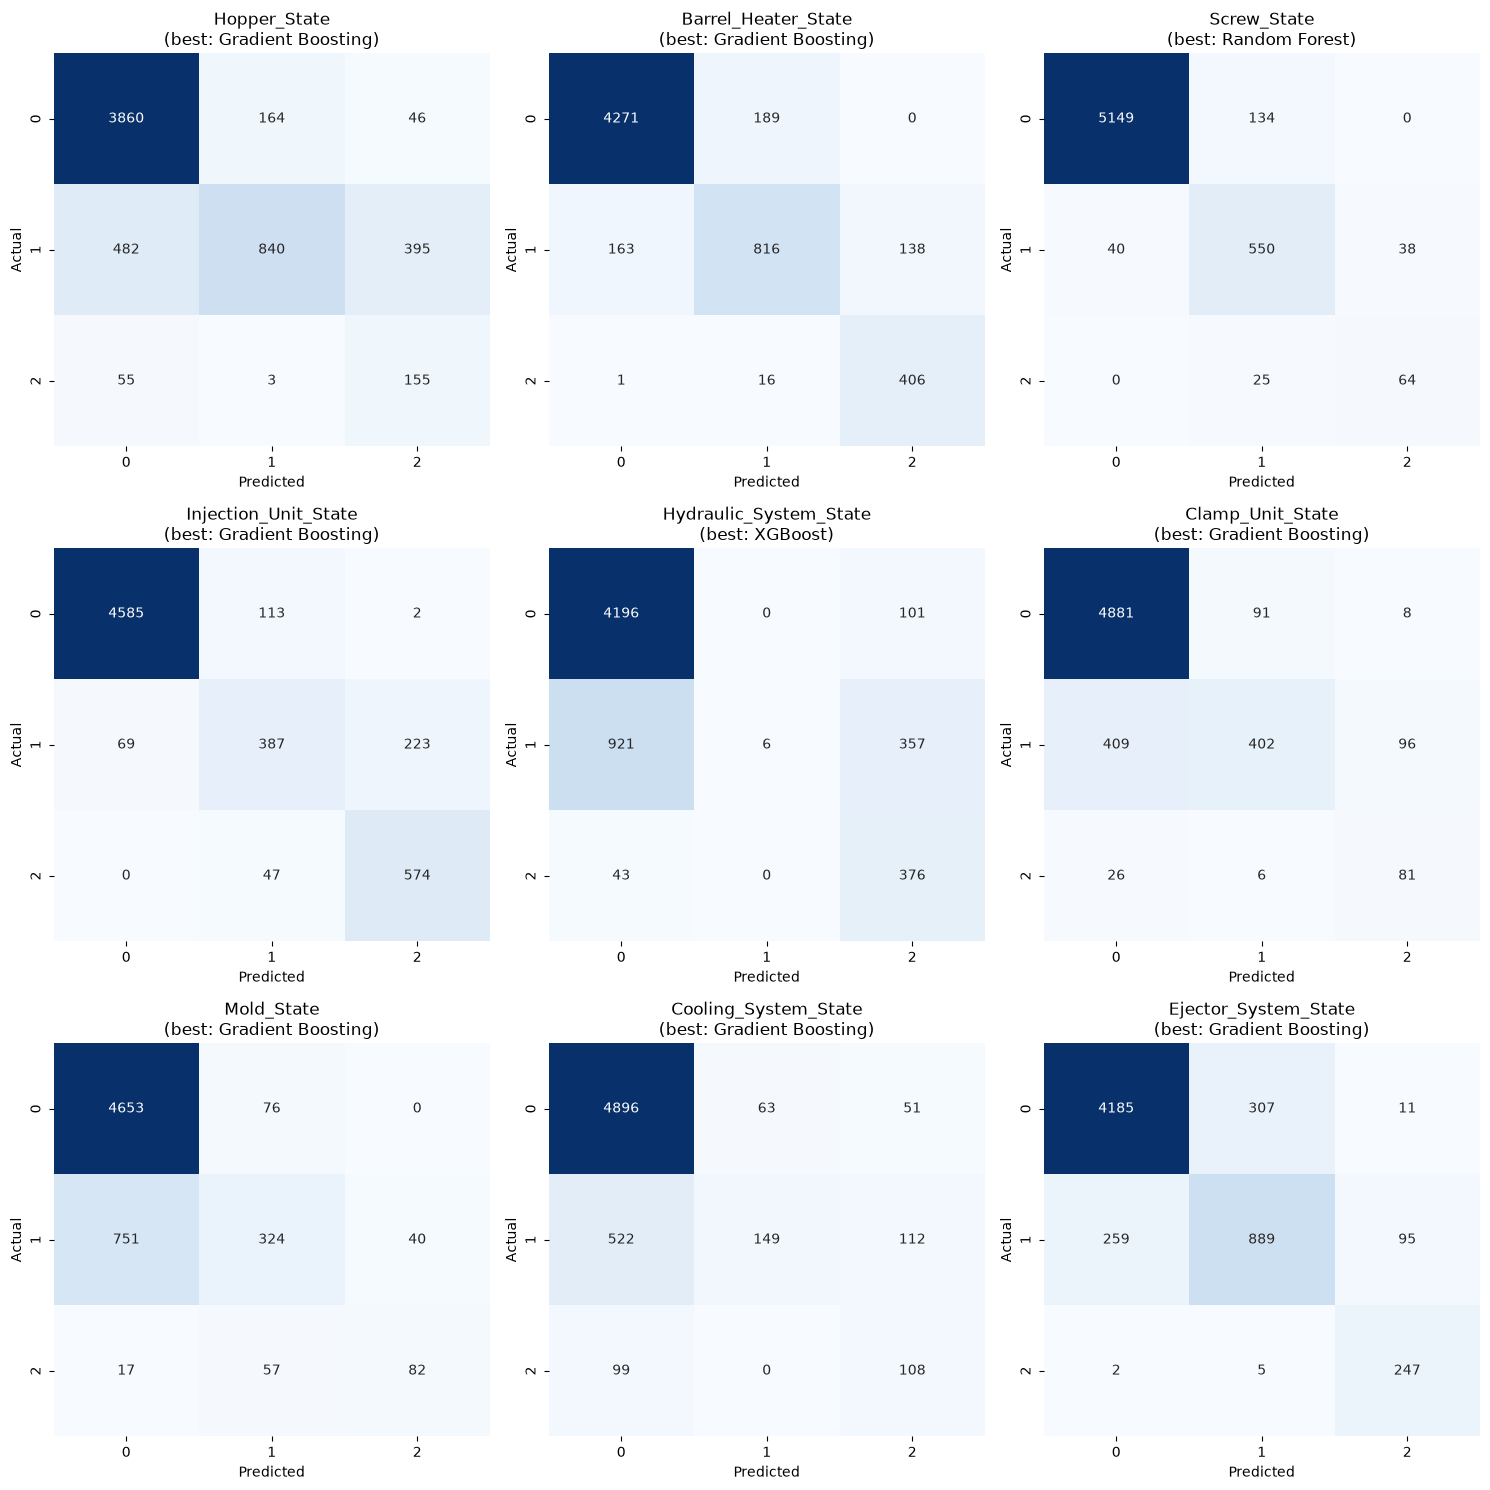

In [60]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, col in zip(axes.flat, target):
    best_model_name = best_model_per_target.loc[col, 'Model']
    model = get_classifiers()[best_model_name]
    fit_classifier(best_model_name, model, X_train, train_df[col])
    y_pred = np.asarray(model.predict(X_test)).reshape(-1)
    cm = confusion_matrix(test_df[col], y_pred, labels=[0, 1, 2])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=[0, 1, 2], yticklabels=[0, 1, 2], ax=ax)
    ax.set_title(f'{col}\n(best: {best_model_name})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()